In [35]:
from pathlib import Path
import subprocess

# ===== 路径设置（相对项目根目录）=====
PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and PROJECT_ROOT.name != "CIMA_multiomics_regulation":
    PROJECT_ROOT = PROJECT_ROOT.parent

if PROJECT_ROOT.name != "CIMA_multiomics_regulation":
    raise RuntimeError("未找到项目根目录 CIMA_multiomics_regulation，请在项目目录内运行该脚本。")

# ===== 核心路径 =====
PFILE_PREFIX = PROJECT_ROOT / "data/processed/genotype/CIMA_BGEID_metaMatched"
PHENO_FILE = PROJECT_ROOT / "data/processed/CIMA/phenotype/CIMA_metabolites_lipids_pheno_plink.tsv"
COVAR_FILE = PROJECT_ROOT / "data/processed/meta/CIMA_plink_covariates.tsv"
OUT_DIR = PROJECT_ROOT / "data/results/gwas"
OUT_DIR.mkdir(parents=True, exist_ok=True)

PHENO_NAME = "Acesulfame"
OUT_PREFIX = OUT_DIR / f"test_{PHENO_NAME}"

# ===== 检查 pfile 三件套 =====
pgen = PFILE_PREFIX.with_suffix(".pgen")
pvar = PFILE_PREFIX.with_suffix(".pvar")
psam = PFILE_PREFIX.with_suffix(".psam")

print("PROJECT_ROOT =", PROJECT_ROOT)
print("PFILE_PREFIX =", PFILE_PREFIX)
print("PHENO_FILE   =", PHENO_FILE)
print("COVAR_FILE   =", COVAR_FILE)
print("OUT_PREFIX   =", OUT_PREFIX)

print("\n=== 文件存在性检查 ===")
for fp in [pgen, pvar, psam, PHENO_FILE, COVAR_FILE]:
    print(fp, fp.exists())
    if not fp.exists():
        raise FileNotFoundError(f"找不到: {fp}")

# ===== 输出文件 =====
GLM_FILE = OUT_DIR / f"test_{PHENO_NAME}.{PHENO_NAME}.glm.linear"
ADD_FILE = OUT_DIR / f"test_{PHENO_NAME}.{PHENO_NAME}.glm.linear.add"

# ===== 1) 跑 plink2 =====
plink_cmd = [
    "plink2",
    "--pfile", str(PFILE_PREFIX),
    "--pheno", str(PHENO_FILE),
    "--maf", "0.05",
    "--hwe", "1e-6",
    "--pheno-name", PHENO_NAME,
    "--covar", str(COVAR_FILE),
    "--covar-name", "SEX,age,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10",
    "--glm", "hide-covar",
    "--threads", "8",
    "--memory", "30000",
    "--out", str(OUT_PREFIX),
]

print("\n=== running plink2 ===")
print(" ".join(plink_cmd))
subprocess.run(plink_cmd, check=True)

if not GLM_FILE.exists():
    raise FileNotFoundError(f"plink2 输出不存在: {GLM_FILE}")

# ===== 2) 提取 TEST=ADD =====
# NR==1 保留表头
# 第10列通常是 TEST，但为了稳一点，先自动找 TEST 列号
awk_script = r'''
BEGIN{FS=OFS="\t"}
NR==1{
    for(i=1;i<=NF;i++){
        if($i=="TEST"){
            test_col=i
        }
    }
    if(!test_col){
        print "ERROR: TEST column not found" > "/dev/stderr"
        exit 1
    }
    print
    next
}
$test_col=="ADD"{print}
'''

print("\n=== extracting ADD rows with awk ===")
with open(ADD_FILE, "w") as fout:
    subprocess.run(
        ["awk", awk_script, str(GLM_FILE)],
        stdout=fout,
        check=True,
        text=True
    )

print(f"saved: {ADD_FILE}")

# ===== 3) 简单统计 =====
n_lines = sum(1 for _ in open(ADD_FILE)) - 1
print(f"ADD rows: {n_lines}")

PROJECT_ROOT = /data/work/CIMA_multiomics_regulation
PFILE_PREFIX = /data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID_metaMatched
PHENO_FILE   = /data/work/CIMA_multiomics_regulation/data/processed/CIMA/phenotype/CIMA_metabolites_lipids_pheno_plink.tsv
COVAR_FILE   = /data/work/CIMA_multiomics_regulation/data/processed/meta/CIMA_plink_covariates.tsv
OUT_PREFIX   = /data/work/CIMA_multiomics_regulation/data/results/gwas/test_Acesulfame

=== 文件存在性检查 ===
/data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID_metaMatched.pgen True
/data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID_metaMatched.pvar True
/data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID_metaMatched.psam True
/data/work/CIMA_multiomics_regulation/data/processed/CIMA/phenotype/CIMA_metabolites_lipids_pheno_plink.tsv True
/data/work/CIMA_multiomics_regulation/data/processed/meta/CIMA_plink_covariates.tsv True

=== running plink2 ===
plink2 --p

In [41]:
%%bash
f=/data/work/CIMA_multiomics_regulation/data/results/gwas/test_Acesulfame.Acesulfame.glm.linear

ls -lh "$f"
wc -l "$f"
head -n 5 "$f"

python - <<'PY'
import pandas as pd

f = "/data/work/CIMA_multiomics_regulation/data/results/gwas/test_Acesulfame.Acesulfame.glm.linear"
df = pd.read_csv(f, sep="\t")

print("shape:", df.shape)
print("columns:", df.columns.tolist())
print("\nTEST counts:")
print(df["TEST"].value_counts(dropna=False))
PY

-rw-r--r--+ 1 stereonote 165636 700M Apr 16 12:04 /data/work/CIMA_multiomics_regulation/data/results/gwas/test_Acesulfame.Acesulfame.glm.linear
7405577 /data/work/CIMA_multiomics_regulation/data/results/gwas/test_Acesulfame.Acesulfame.glm.linear
#CHROM	POS	ID	REF	ALT	PROVISIONAL_REF?	A1	OMITTED	A1_FREQ	TEST	OBS_CT	BETA	SE	T_STAT	P	ERRCODE
1	94134	chr1_94134	C	T	N	T	C	0.0552561	ADD	371	0.0671429	0.0480757	1.39661	0.163399	.
1	94321	chr1_94321	C	T	N	T	C	0.0552561	ADD	371	0.0671429	0.0480757	1.39661	0.163399	.
1	95045	chr1_95045	A	G	N	G	A	0.0552561	ADD	371	0.0671429	0.0480757	1.39661	0.163399	.
1	95622	chr1_95622	G	A	N	A	G	0.0552561	ADD	371	0.0671429	0.0480757	1.39661	0.163399	.
shape: (7405576, 16)
columns: ['#CHROM', 'POS', 'ID', 'REF', 'ALT', 'PROVISIONAL_REF?', 'A1', 'OMITTED', 'A1_FREQ', 'TEST', 'OBS_CT', 'BETA', 'SE', 'T_STAT', 'P', 'ERRCODE']

TEST counts:
TEST
ADD    7405576
Name: count, dtype: int64


## Manhattan 图

这一步直接读取 plink2 的 `.glm.linear.add` 结果文件，画一个不带基因注释的 Manhattan 图。

这个版本只依赖结果文件本身，适合先快速检查：

- 有没有明显信号
- 染色体分布是否正常
- p 值范围是否合理

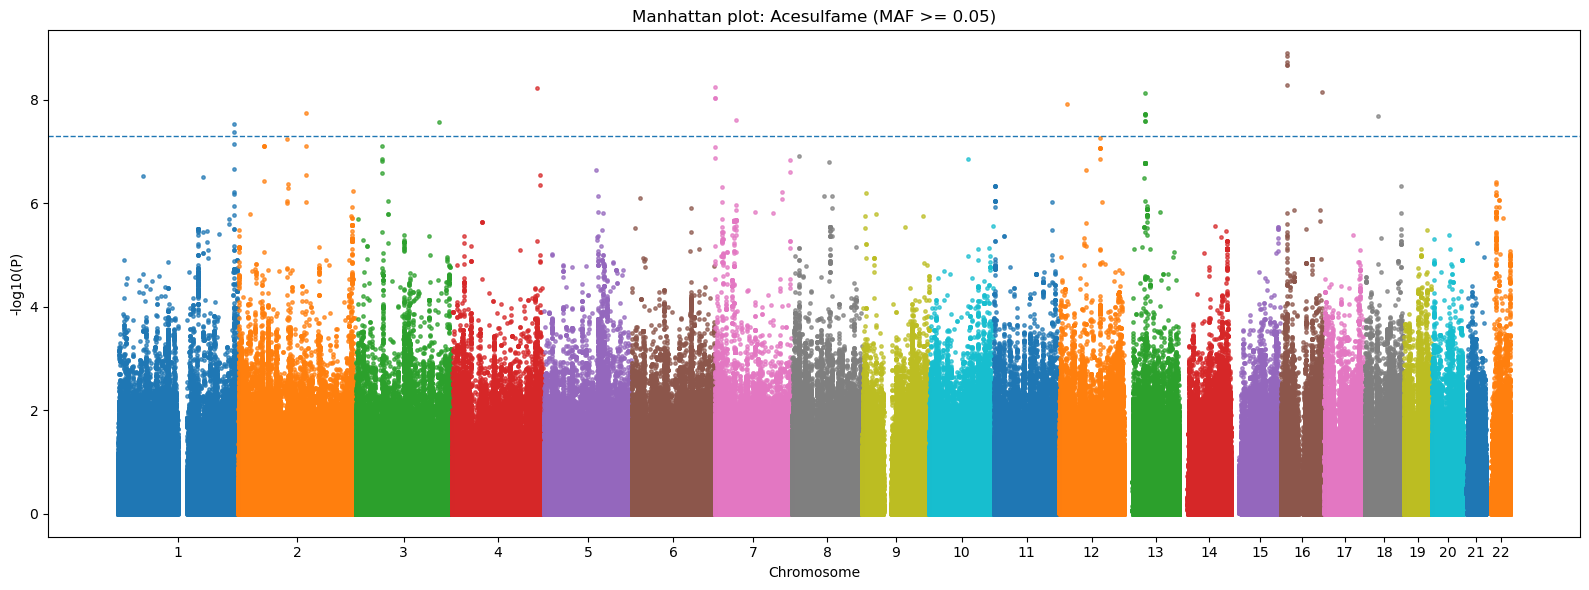

saved: /data/work/CIMA_multiomics_regulation/data/results/gwas/test_Acesulfame.manhattan.maf05.png
filtered shape: (6808832, 7)


In [37]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULT_FILE = PROJECT_ROOT / "data/results/gwas/test_Acesulfame.Acesulfame.glm.linear.add"
OUT_PNG = PROJECT_ROOT / "data/results/gwas/test_Acesulfame.manhattan.maf05.png"

# 只读必要列
plot_df = pd.read_csv(
    RESULT_FILE,
    sep="\t",
    usecols=["#CHROM", "POS", "P", "A1_FREQ"]
)

# 类型转换
plot_df["P"] = pd.to_numeric(plot_df["P"], errors="coerce")
plot_df["POS"] = pd.to_numeric(plot_df["POS"], errors="coerce")
plot_df["A1_FREQ"] = pd.to_numeric(plot_df["A1_FREQ"], errors="coerce")

# 染色体整理
plot_df["#CHROM"] = plot_df["#CHROM"].astype(str).str.replace("^chr", "", regex=True)
plot_df = plot_df[plot_df["#CHROM"].isin([str(i) for i in range(1, 23)] + ["X"])]

plot_df["#CHROM"] = plot_df["#CHROM"].replace({"X": "23"}).astype(int)

# 基本过滤
plot_df = plot_df.dropna(subset=["#CHROM", "POS", "P", "A1_FREQ"])
plot_df = plot_df[(plot_df["P"] > 0) & (plot_df["P"] <= 1)]

# 真正按 MAF 过滤
plot_df["MAF"] = np.minimum(plot_df["A1_FREQ"], 1 - plot_df["A1_FREQ"])
plot_df = plot_df[plot_df["MAF"] >= 0.05]

# 计算 -log10(P)
plot_df["minus_log10_p"] = -np.log10(plot_df["P"])

# 排序
plot_df = plot_df.sort_values(["#CHROM", "POS"]).reset_index(drop=True)

# 计算 cumulative BP
chr_max = plot_df.groupby("#CHROM", sort=True)["POS"].max()
chr_offset = chr_max.cumsum().shift(fill_value=0).to_dict()

plot_df["BP_cum"] = plot_df["POS"] + plot_df["#CHROM"].map(chr_offset)

# 每条染色体中心位置
chr_center = (
    plot_df.groupby("#CHROM", sort=True)["BP_cum"]
    .agg(["min", "max"])
)
chr_center["center"] = (chr_center["min"] + chr_center["max"]) / 2

# 画图
plt.figure(figsize=(16, 6))

for chrom, sub in plot_df.groupby("#CHROM", sort=True):
    plt.scatter(sub["BP_cum"], sub["minus_log10_p"], s=6, alpha=0.7)

plt.axhline(-np.log10(5e-8), linestyle="--", linewidth=1)

plt.xticks(
    chr_center["center"],
    [str(c) if c != 23 else "X" for c in chr_center.index]
)
plt.xlabel("Chromosome")
plt.ylabel("-log10(P)")
plt.title("Manhattan plot: Acesulfame (MAF >= 0.05)")
plt.tight_layout()
plt.savefig(OUT_PNG, dpi=150, bbox_inches="tight")
plt.show()

print("saved:", OUT_PNG)
print("filtered shape:", plot_df.shape)